In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from sklearn.feature_selection import SelectKBest, f_classif
import time

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

**Limpeza (da entrega 2)**

In [149]:
url = 'https://raw.githubusercontent.com/MillenaNeves/Ciencia-de-dados/main/acidentes_recife_2024%20(1).csv'
df = pd.read_csv(url, sep=';', decimal=',')

# removendo colunas com muitos valores nulos ou que não contribuem para a predição
colunas_remover = ['situacao_semaforo', 'tempo_clima', 'acidente_verificado', 'mao_direcao',
                   'conservacao_via', 'ponto_controle', 'velocidade_max_via', 'divisao_via2',
                   'divisao_via1', 'num_semaforo', 'condicao_via', 'sinalizacao', 'situacao_placa',
                   'Protocolo', 'endereco', 'numero', 'detalhe_endereco_acidente', 'complemento',
                   'bairro_cruzamento', 'data', 'hora']
df.drop(columns=colunas_remover, errors='ignore', inplace=True)

# limpeza da variável alvo e preenchimento de nulos nas features categóricas
df.dropna(subset=['natureza'], inplace=True)
df = df[~df['natureza'].isin(['APOIO', 'ENTRADA E SAÍDA'])]

cat_cols = [c for c in df.columns if df[c].dtype == 'object' and c != 'natureza']
df[cat_cols] = df[cat_cols].fillna('N/A')

# tratamento de outliers nas variáveis numéricas utilizando o método IQR
num_cols = ['auto', 'moto', 'ciclom', 'ciclista', 'pedestre', 'onibus', 'caminhao', 'vitimas']
for col in num_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    df[col] = df[col].clip(lower=q1 - 1.5*iqr, upper=q3 + 1.5*iqr)

**Pipeline de Transformação (Scaling e Encoding)**

In [150]:
# Separação de atributos e alvo
X = df.drop(columns=['natureza'])
y = df['natureza']

# Divisão dos dados em Treino e Teste (70/30) com estratificação
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 1. Pipeline de Transformação (Scaling e Encoding)
pipe_prep = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols)
])

# aplicando as transformações iniciais (gerando as 125 colunas)
X_train_transf = pipe_prep.fit_transform(X_train)
X_test_transf = pipe_prep.transform(X_test)

**Consolidação da seleção de features (Melhor método da Entrega 3)**

In [151]:
# isso reduz o ruído de 125 para as 15 melhores colunas ANTES do SMOTE rodar
selector = SelectKBest(score_func=f_classif, k=15)
X_train_fix = selector.fit_transform(X_train_transf, y_train)
X_test_fix = selector.transform(X_test_transf)

print(f"Estrutura original após Encoding/Scaling: {X_train_transf.shape}")
print(f"Total de features consolidadas para o balanceamento: {X_train_fix.shape[1]}")

Estrutura original após Encoding/Scaling: (3720, 125)
Total de features consolidadas para o balanceamento: 15


**Treinamento do modelo kNN com os dados originais (desbalanceados)**

In [152]:
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train_fix, y_train)
y_pred_base = knn_base.predict(X_test_fix)

print("Resultados do modelo kNN Baseline (sem balanceamento):")
print(classification_report(y_test, y_pred_base))

Resultados do modelo kNN Baseline (sem balanceamento):
              precision    recall  f1-score   support

  COM VÍTIMA       0.92      0.98      0.95      1402
  SEM VÍTIMA       0.74      0.43      0.54       183
VÍTIMA FATAL       0.00      0.00      0.00        10

    accuracy                           0.91      1595
   macro avg       0.56      0.47      0.50      1595
weighted avg       0.90      0.91      0.90      1595



**Aplicação do SMOTE para gerar amostras sintéticas das classes minoritárias no conjunto de treino**
- O k_neighbors foi ajustado para 3 devido ao baixo número de registros da classe vítima fatal

In [153]:
smote = SMOTE(random_state=42, k_neighbors=3)
X_resampled, y_resampled = smote.fit_resample(X_train_fix, y_train)

print(f"Distribuição das classes antes do balanceamento: \n{y_train.value_counts()}\n")
print(f"Distribuição das classes após o SMOTE: \n{y_resampled.value_counts()}")

Distribuição das classes antes do balanceamento: 
natureza
COM VÍTIMA      3269
SEM VÍTIMA       427
VÍTIMA FATAL      24
Name: count, dtype: int64

Distribuição das classes após o SMOTE: 
natureza
COM VÍTIMA      3269
SEM VÍTIMA      3269
VÍTIMA FATAL    3269
Name: count, dtype: int64


In [154]:
knn_final = KNeighborsClassifier(n_neighbors=5)
knn_final.fit(X_resampled, y_resampled)
y_pred_final = knn_final.predict(X_test_fix)

print("Resultados do modelo kNN após balanceamento (SMOTE):")
print(classification_report(y_test, y_pred_final))

Resultados do modelo kNN após balanceamento (SMOTE):
              precision    recall  f1-score   support

  COM VÍTIMA       0.93      0.98      0.95      1402
  SEM VÍTIMA       0.75      0.45      0.56       183
VÍTIMA FATAL       0.00      0.00      0.00        10

    accuracy                           0.91      1595
   macro avg       0.56      0.48      0.50      1595
weighted avg       0.90      0.91      0.90      1595



**Aplicação do over-sampling**

In [155]:
print(f"Distribuição das classes antes do balanceamento: \n{y_train.value_counts()}\n")
print(f"Distribuição das classes após o Random Over-Sampling: \n{y_ros.value_counts()}\n")

print("Random Over-Sampling - Classification Report:")
print(classification_report(y_test, y_pred_ros))

# Obtenção das probabilidades para o cálculo do AUC e ROC
y_prob_ros = knn_ros.predict_proba(X_test_fix)

# classes existentes no modelo (garantir que está definido)
classes = knn_ros.classes_

# binarização do y_test para plotar a curva ROC
y_test_bin_ros = label_binarize(y_test, classes=classes)
n_classes_ros = y_test_bin_ros.shape[1]

# Cálculo do Score AUC
auc_ros = roc_auc_score(y_test, y_prob_ros, multi_class='ovr')
print(f"AUC Global com Random Over-Sampling (OvR): {auc_ros:.4f}\n")

Distribuição das classes antes do balanceamento: 
natureza
COM VÍTIMA      3269
SEM VÍTIMA       427
VÍTIMA FATAL      24
Name: count, dtype: int64

Distribuição das classes após o Random Over-Sampling: 
natureza
COM VÍTIMA      3269
SEM VÍTIMA      3269
VÍTIMA FATAL    3269
Name: count, dtype: int64

Random Over-Sampling - Classification Report:
              precision    recall  f1-score   support

  COM VÍTIMA       0.93      0.96      0.95      1402
  SEM VÍTIMA       0.65      0.48      0.55       183
VÍTIMA FATAL       0.00      0.00      0.00        10

    accuracy                           0.90      1595
   macro avg       0.53      0.48      0.50      1595
weighted avg       0.89      0.90      0.89      1595

AUC Global com Random Over-Sampling (OvR): 0.7163



**Aplicando técnica de undersampling**

In [156]:
print(f"Distribuição das classes após Undersampling: \n{pd.Series(y_rus).value_counts()}\n")

# treinando o kNN com os dados do Undersampling
knn_rus = KNeighborsClassifier(n_neighbors=5)
knn_rus.fit(X_rus, y_rus)

# predição e Avaliação
y_pred_rus = knn_rus.predict(X_test_fix)

print("\nResultados do modelo kNN após balanceamento (Undersampling):")
print(classification_report(y_test, y_pred_rus))

# Obtenção das probabilidades para o cálculo do AUC e ROC
y_prob_rus = knn_rus.predict_proba(X_test_fix)

# classes existentes no modelo (garantir que está definido)
classes = knn_rus.classes_

# binarização do y_test para plotar a curva ROC
y_test_bin_rus = label_binarize(y_test, classes=classes)
n_classes_rus = y_test_bin_rus.shape[1]

# Cálculo do Score AUC
auc_rus = roc_auc_score(y_test, y_prob_rus, multi_class='ovr')
print(f"AUC Global com Random Under-Sampling (OvR): {auc_rus:.4f}\n")

Distribuição das classes após Undersampling: 
natureza
COM VÍTIMA      24
SEM VÍTIMA      24
VÍTIMA FATAL    24
Name: count, dtype: int64


Resultados do modelo kNN após balanceamento (Undersampling):
              precision    recall  f1-score   support

  COM VÍTIMA       0.92      0.82      0.87      1402
  SEM VÍTIMA       0.27      0.42      0.33       183
VÍTIMA FATAL       0.00      0.00      0.00        10

    accuracy                           0.77      1595
   macro avg       0.40      0.41      0.40      1595
weighted avg       0.84      0.77      0.80      1595

AUC Global com Random Under-Sampling (OvR): 0.6954



 **Calculando os tempos de execução para o gráfico de custo:**

In [157]:
# medindo o tempo do Baseline (sem balanceamento)
start_base = time.time()
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train_fix, y_train)
_ = knn_base.predict(X_test_fix)
tempo_baseline = time.time() - start_base
print(f"Tempo de execução Baseline: {tempo_baseline:.4f} segundos")


# medindo o tempo do Under-Sampling
start_rus = time.time()
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train_fix, y_train)
knn_rus = KNeighborsClassifier(n_neighbors=5)
knn_rus.fit(X_rus, y_rus)
_ = knn_rus.predict(X_test_fix)
tempo_rus = time.time() - start_rus
print(f"Tempo de execução do Under-Sampling: {tempo_rus:.4f} segundos")

# medindo o tempo do SMOTE
start_smote = time.time()
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_fix, y_train)
knn_smote = KNeighborsClassifier(n_neighbors=5)
knn_smote.fit(X_smote, y_smote)
_ = knn_smote.predict(X_test_fix)
tempo_smote = time.time() - start_smote
print(f"Tempo de execução do SMOTE: {tempo_smote:.4f} segundos")

#medindo o tempo do Over-Sampling
start_time = time.time()
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train_fix, y_train)
knn_ros = KNeighborsClassifier(n_neighbors=5)
knn_ros.fit(X_ros, y_ros)
y_pred_ros = knn_ros.predict(X_test_fix)
tempo_ros = time.time() - start_time
print(f"Tempo de execução do Over-Sampling: {tempo_ros:.4f} segundos")


Tempo de execução Baseline: 0.0851 segundos
Tempo de execução do Under-Sampling: 0.0167 segundos
Tempo de execução do SMOTE: 0.2278 segundos
Tempo de execução do Over-Sampling: 0.2513 segundos


**Custo computacional**

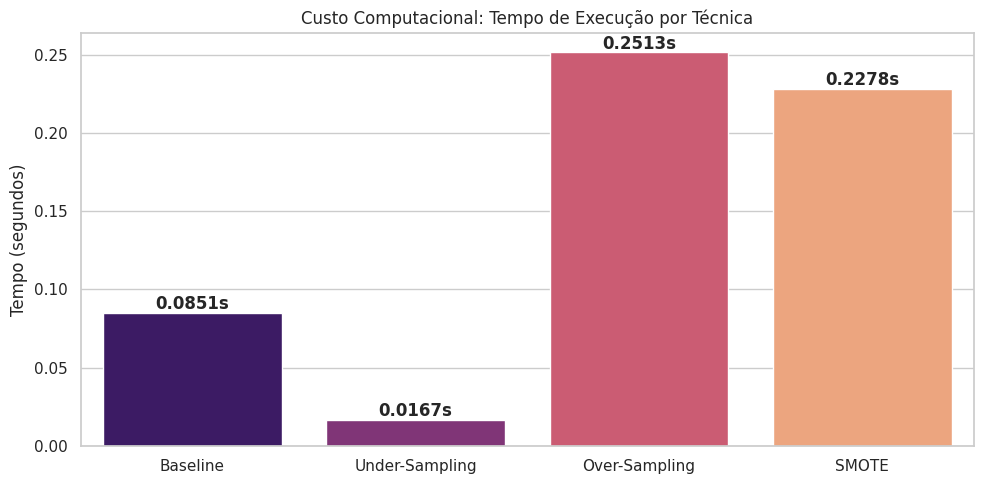

In [158]:
tempos = [tempo_baseline, tempo_rus, tempo_ros, tempo_smote]
metodos = ['Baseline', 'Under-Sampling', 'Over-Sampling', 'SMOTE']

plt.figure(figsize=(10, 5))
sns.barplot(x=metodos, y=tempos, palette='magma')
plt.title('Custo Computacional: Tempo de Execução por Técnica')
plt.ylabel('Tempo (segundos)')

for i, v in enumerate(tempos):
    plt.text(i, v + (max(tempos) * 0.01), f"{v:.4f}s", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Comparação da distribuição de classes**

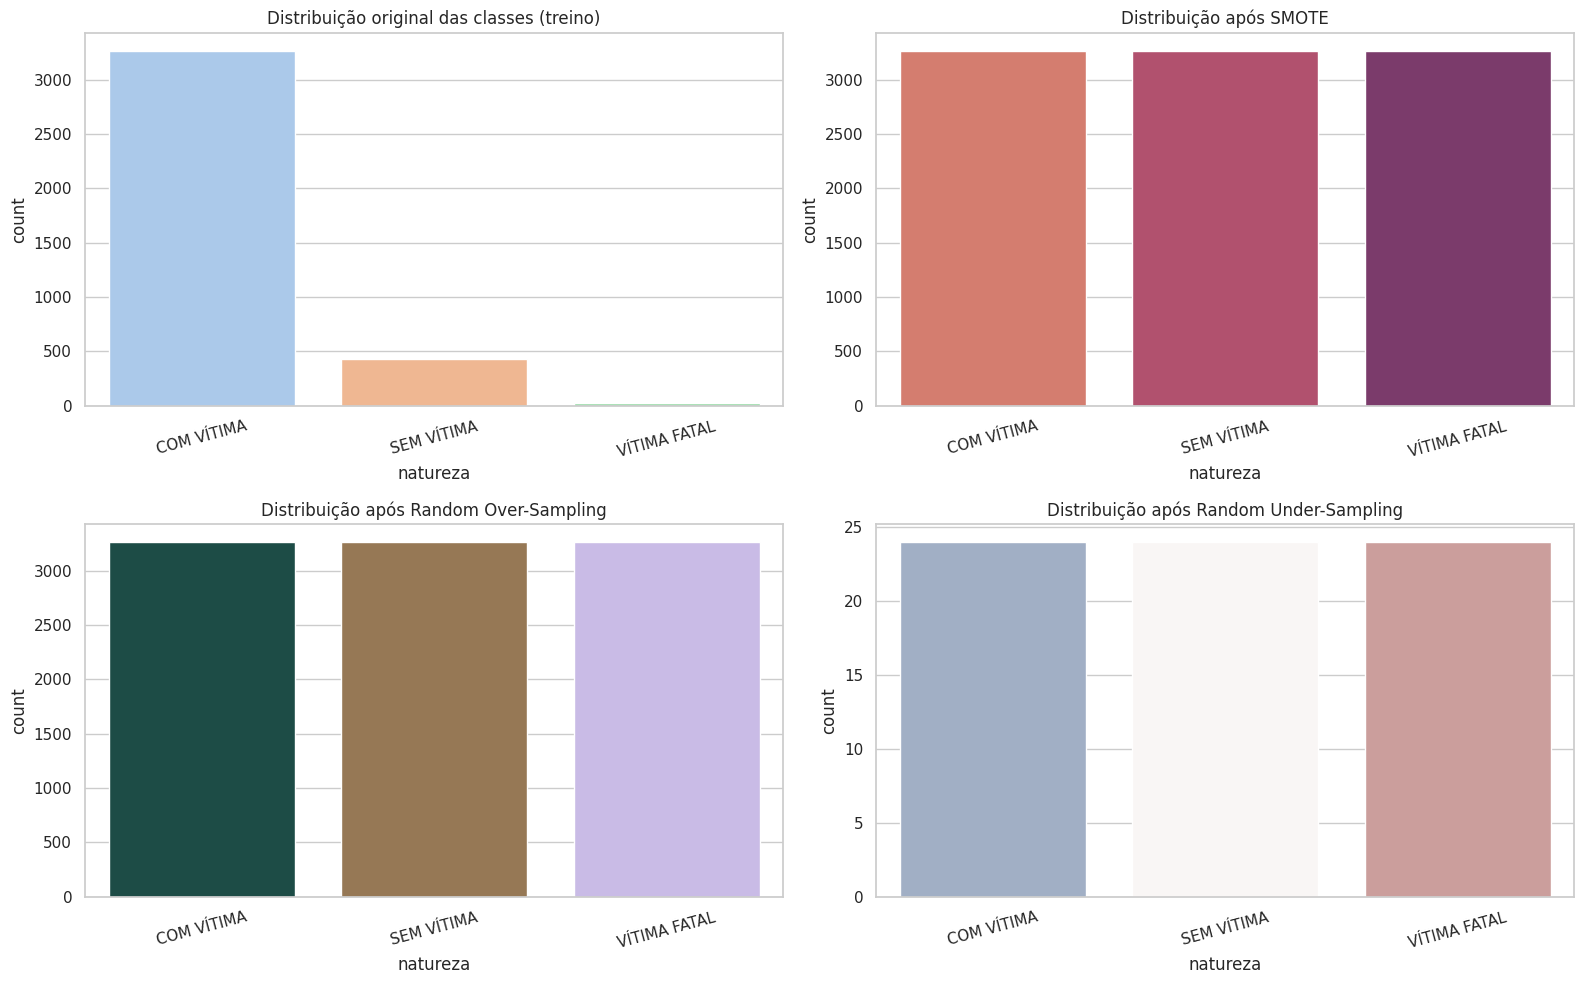

In [159]:
fig, ax = plt.subplots(2, 2, figsize=(16, 10))

ordem_classes = ['COM VÍTIMA', 'SEM VÍTIMA', 'VÍTIMA FATAL']

# ORIGINAL
sns.countplot(x=y_train, ax=ax[0,0], palette='pastel', order=ordem_classes)
ax[0,0].set_title('Distribuição original das classes (treino)')
ax[0,0].tick_params(axis='x', rotation=15)

# SMOTE
sns.countplot(x=y_resampled, ax=ax[0,1], palette='flare', order=ordem_classes)
ax[0,1].set_title('Distribuição após SMOTE')
ax[0,1].tick_params(axis='x', rotation=15)

# RANDOM OVER-SAMPLING
sns.countplot(x=y_ros, ax=ax[1,0], palette='cubehelix', order=ordem_classes)
ax[1,0].set_title('Distribuição após Random Over-Sampling')
ax[1,0].tick_params(axis='x', rotation=15)

# RANDOM UNDER-SAMPLING
sns.countplot(x=y_rus, ax=ax[1,1], palette='vlag', order=ordem_classes)
ax[1,1].set_title('Distribuição após Random Under-Sampling')
ax[1,1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

**Visualização do espaço de features usando PCA**

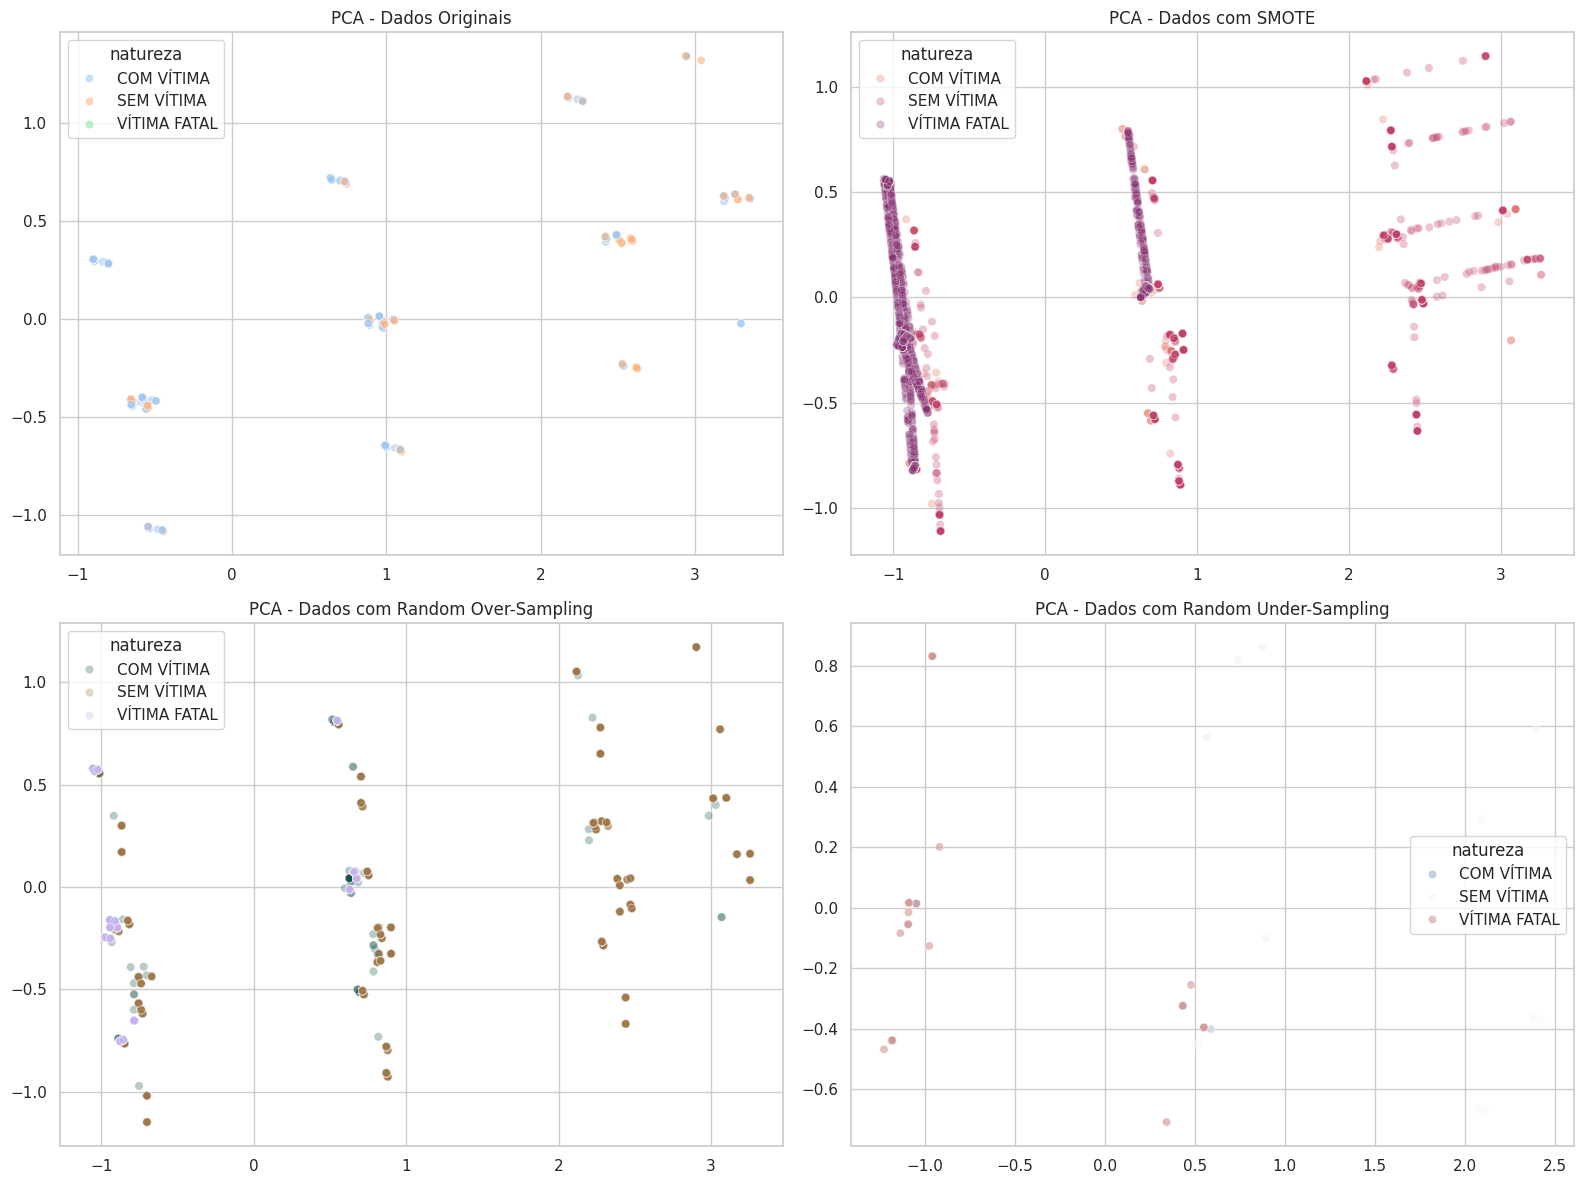

In [160]:
pca_orig = PCA(n_components=2)
X_pca_orig = pca_orig.fit_transform(X_train_fix)

# PCA SMOTE
pca_smote = PCA(n_components=2)
X_pca_smote = pca_smote.fit_transform(X_resampled)

# PCA Over-Sampling
pca_ros = PCA(n_components=2)
X_pca_ros = pca_ros.fit_transform(X_ros)

# PCA Under-Sampling
pca_rus = PCA(n_components=2)
X_pca_rus = pca_rus.fit_transform(X_rus)

fig, ax = plt.subplots(2, 2, figsize=(16, 12))

# ORIGINAL
sns.scatterplot(
    x=X_pca_orig[:,0],
    y=X_pca_orig[:,1],
    hue=y_train,
    alpha=0.6,
    ax=ax[0,0],
    palette='pastel',
    hue_order=ordem_classes
)
ax[0,0].set_title('PCA - Dados Originais')

# SMOTE
sns.scatterplot(
    x=X_pca_smote[:,0],
    y=X_pca_smote[:,1],
    hue=y_resampled,
    alpha=0.3,
    ax=ax[0,1],
    palette='flare',
    hue_order=ordem_classes
)
ax[0,1].set_title('PCA - Dados com SMOTE')

# OVER-SAMPLING
sns.scatterplot(
    x=X_pca_ros[:,0],
    y=X_pca_ros[:,1],
    hue=y_ros,
    alpha=0.3,
    ax=ax[1,0],
    palette='cubehelix',
    hue_order=ordem_classes
)
ax[1,0].set_title('PCA - Dados com Random Over-Sampling')

# UNDER-SAMPLING
sns.scatterplot(
    x=X_pca_rus[:,0],
    y=X_pca_rus[:,1],
    hue=y_rus,
    alpha=0.6,
    ax=ax[1,1],
    palette='vlag',
    hue_order=ordem_classes
)
ax[1,1].set_title('PCA - Dados com Random Under-Sampling')

plt.tight_layout()
plt.show()

**Visualização comparativa das matrizes de confusão**

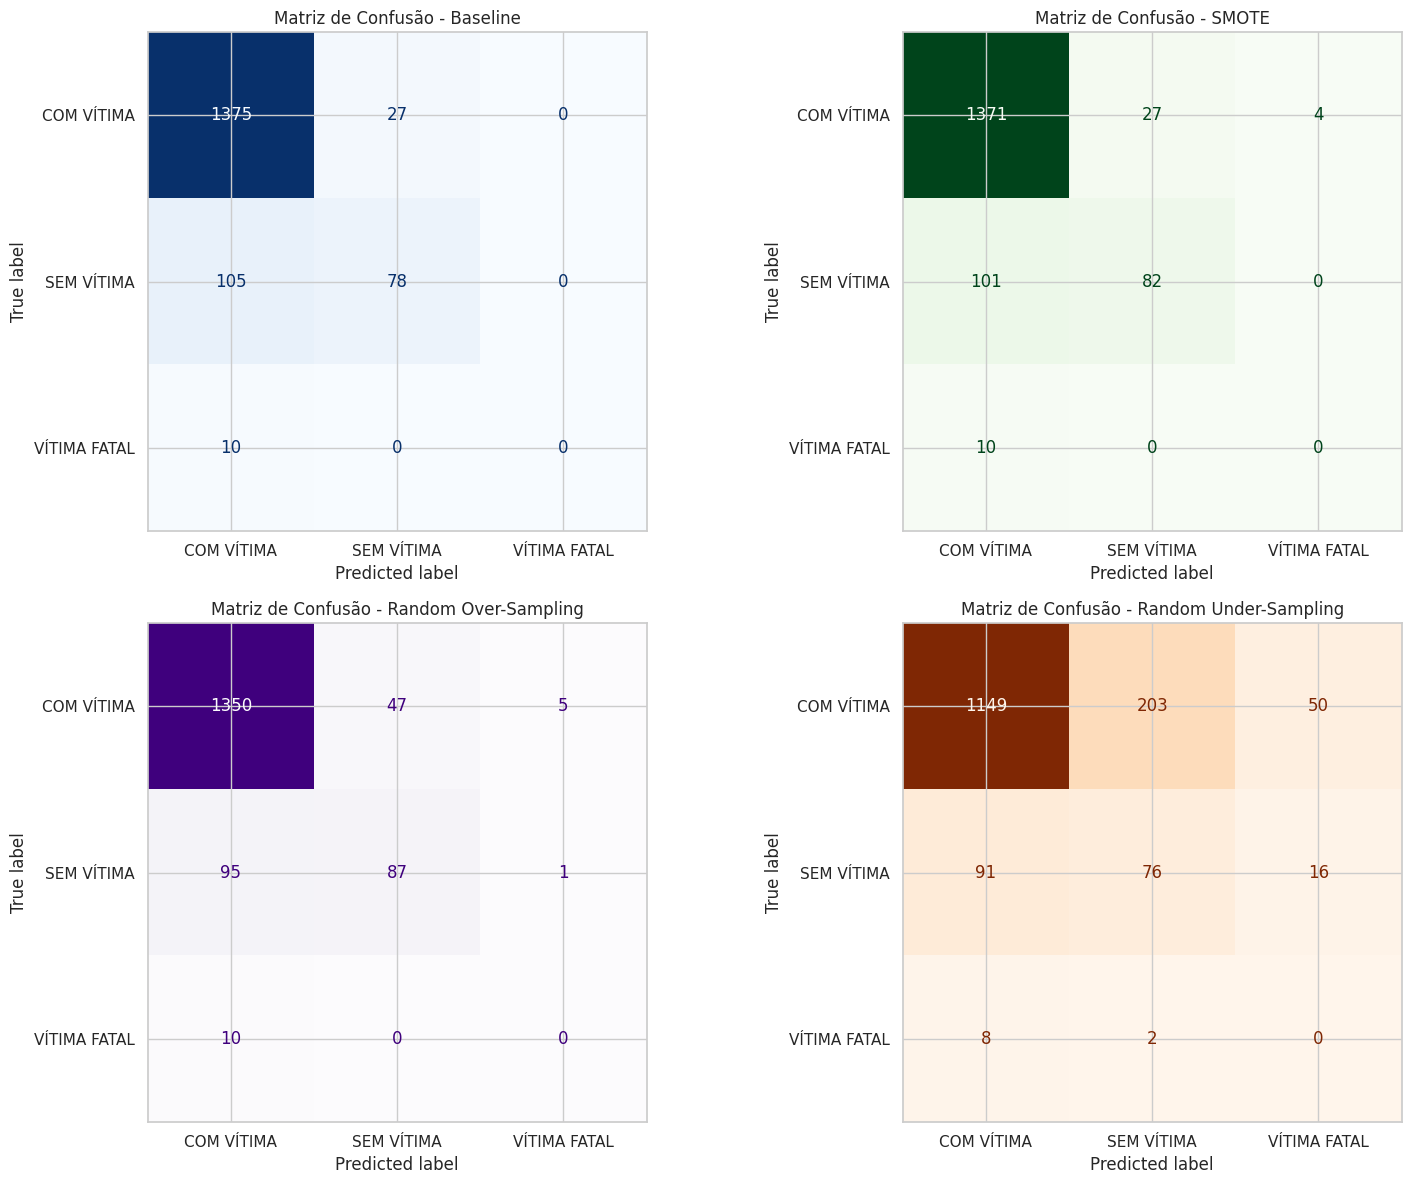

In [161]:
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

# BASELINE
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_base,
    ax=ax[0,0],
    cmap='Blues',
    colorbar=False
)
ax[0,0].set_title('Matriz de Confusão - Baseline')

# SMOTE
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final,
    ax=ax[0,1],
    cmap='Greens',
    colorbar=False
)
ax[0,1].set_title('Matriz de Confusão - SMOTE')

# OVER-SAMPLING
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_ros,
    ax=ax[1,0],
    cmap='Purples',
    colorbar=False
)
ax[1,0].set_title('Matriz de Confusão - Random Over-Sampling')

# UNDER-SAMPLING
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rus,
    ax=ax[1,1],
    cmap='Oranges',
    colorbar=False
)
ax[1,1].set_title('Matriz de Confusão - Random Under-Sampling')

plt.tight_layout()
plt.show()

AUC Global do Baseline (OvR): 0.7101
AUC Global com SMOTE (OvR):   0.7147


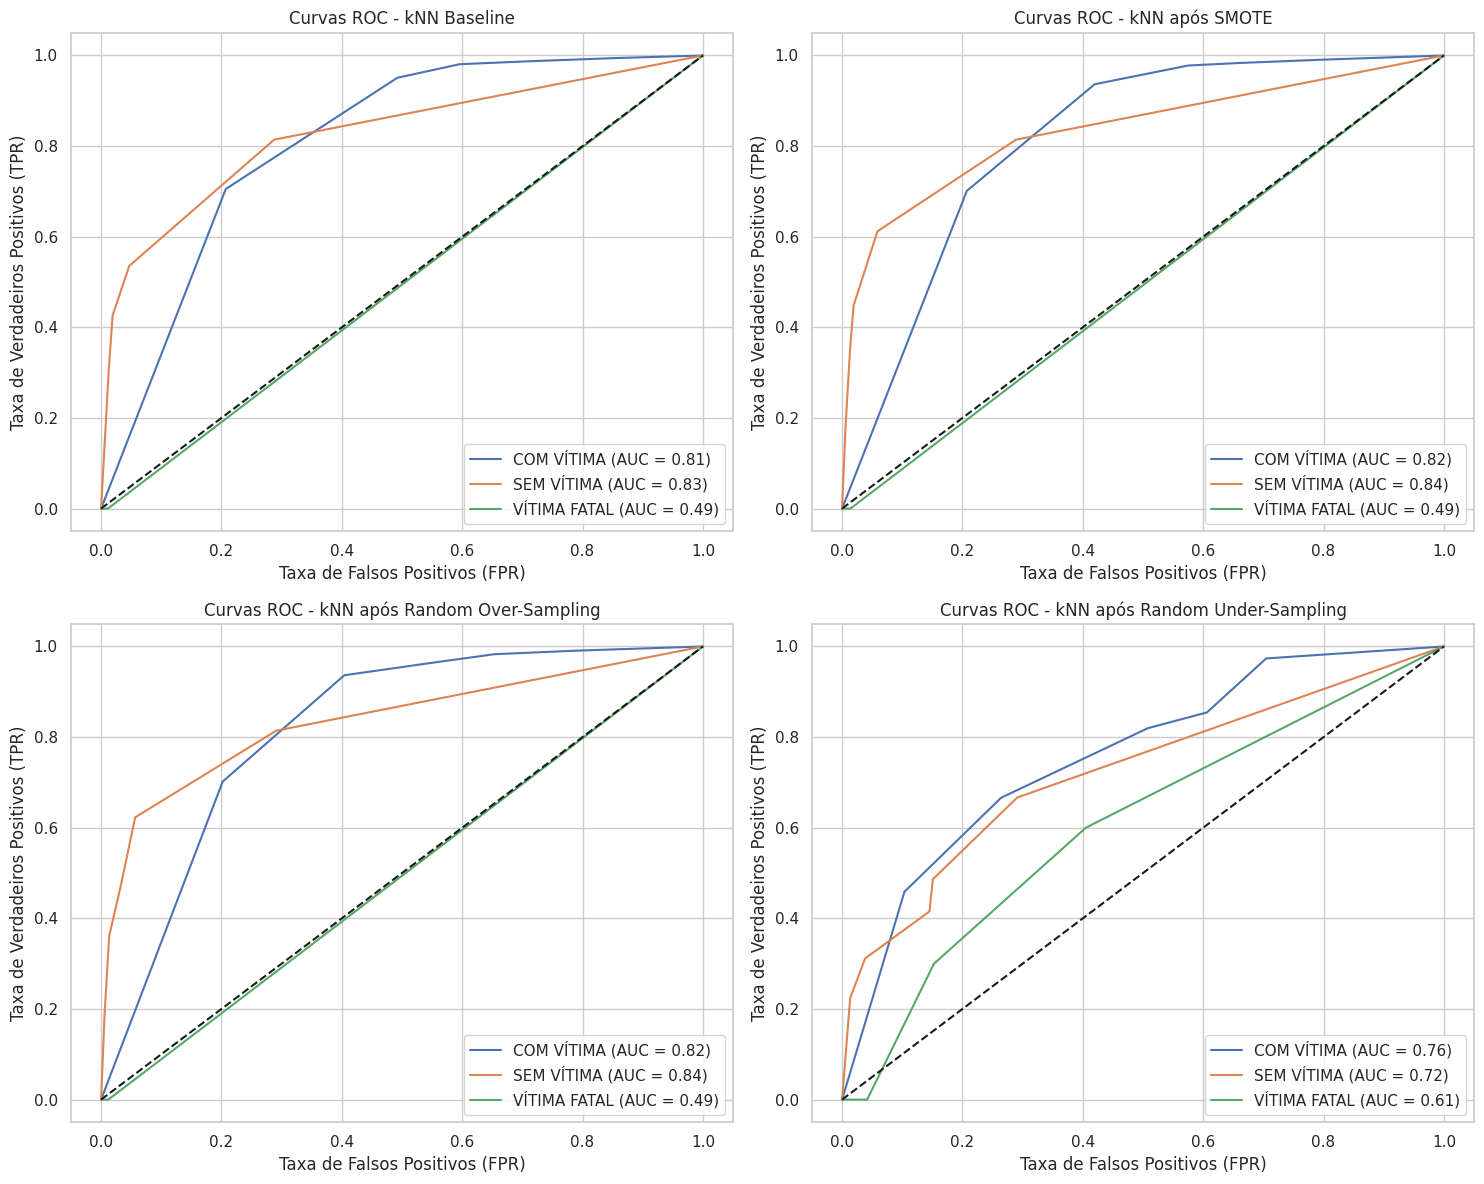

In [162]:
# obtenção das probabilidades ao invés de apenas as classes preditas
y_prob_base = knn_base.predict_proba(X_test_fix)
y_prob_final = knn_final.predict_proba(X_test_fix)

# classes existentes no modelo
classes = knn_base.classes_

# binarização do y_test para plotar a curva ROC
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# cálculo do Score AUC
auc_base = roc_auc_score(y_test, y_prob_base, multi_class='ovr')
auc_final = roc_auc_score(y_test, y_prob_final, multi_class='ovr')

print(f"AUC Global do Baseline (OvR): {auc_base:.4f}")
print(f"AUC Global com SMOTE (OvR):   {auc_final:.4f}")
# plot das Curvas ROC
fig, ax = plt.subplots(2, 2, figsize=(15, 12))

# BASELINE
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_base[:, i])
    roc_auc = auc(fpr, tpr)
    ax[0, 0].plot(fpr, tpr, label=f'{classes[i]} (AUC = {roc_auc:.2f})')

ax[0, 0].plot([0, 1], [0, 1], 'k--')
ax[0, 0].set_title('Curvas ROC - kNN Baseline')
ax[0, 0].set_xlabel('Taxa de Falsos Positivos (FPR)')
ax[0, 0].set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
ax[0, 0].legend(loc='lower right')


# SMOTE
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_final[:, i])
    roc_auc = auc(fpr, tpr)
    ax[0, 1].plot(fpr, tpr, label=f'{classes[i]} (AUC = {roc_auc:.2f})')

ax[0, 1].plot([0, 1], [0, 1], 'k--')
ax[0, 1].set_title('Curvas ROC - kNN após SMOTE')
ax[0, 1].set_xlabel('Taxa de Falsos Positivos (FPR)')
ax[0, 1].set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
ax[0, 1].legend(loc='lower right')


# RANDOM OVER-SAMPLING
for i in range(n_classes_ros):
    fpr, tpr, _ = roc_curve(y_test_bin_ros[:, i], y_prob_ros[:, i])
    roc_auc = auc(fpr, tpr)
    ax[1, 0].plot(fpr, tpr, label=f'{classes[i]} (AUC = {roc_auc:.2f})')

ax[1, 0].plot([0, 1], [0, 1], 'k--')
ax[1, 0].set_title('Curvas ROC - kNN após Random Over-Sampling')
ax[1, 0].set_xlabel('Taxa de Falsos Positivos (FPR)')
ax[1, 0].set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
ax[1, 0].legend(loc='lower right')


# RANDOM UNDER-SAMPLING
for i in range(n_classes_rus):
    fpr, tpr, _ = roc_curve(y_test_bin_rus[:, i], y_prob_rus[:, i])
    roc_auc = auc(fpr, tpr)
    ax[1, 1].plot(fpr, tpr, label=f'{classes[i]} (AUC = {roc_auc:.2f})')

ax[1, 1].plot([0, 1], [0, 1], 'k--')
ax[1, 1].set_title('Curvas ROC - kNN após Random Under-Sampling')
ax[1, 1].set_xlabel('Taxa de Falsos Positivos (FPR)')
ax[1, 1].set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
ax[1, 1].legend(loc='lower right')

plt.tight_layout()
plt.show()

 **Consolidação das métricas para comparação final**

In [163]:
res = pd.DataFrame({
    'Métrica': ['Acurácia', 'F1-Score Macro', 'AUC Global'],

    'Baseline': [
        accuracy_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_base, average='macro'),
        roc_auc_score(y_test, y_prob_base, multi_class='ovr')
    ],

    'SMOTE': [
        accuracy_score(y_test, y_pred_final),
        f1_score(y_test, y_pred_final, average='macro'),
        roc_auc_score(y_test, y_prob_final, multi_class='ovr')
    ],

    'Random Over-Sampling': [
        accuracy_score(y_test, y_pred_ros),
        f1_score(y_test, y_pred_ros, average='macro'),
        auc_ros
    ],

    'Random Under-Sampling': [
        accuracy_score(y_test, y_pred_rus),
        f1_score(y_test, y_pred_rus, average='macro'),
        auc_rus
    ]
})

display(res)

,Métrica,Baseline,SMOTE,Random Over-Sampling,Random Under-Sampling
0,Acurácia,0.910972,0.910972,0.900940,0.768025
1,F1-Score Macro,0.497522,0.504136,0.497981,0.398252
2,AUC Global,0.710134,0.714663,0.716286,0.695394
